# Task
Perform K-means clustering on the dataset from `/content/encoded_df_final.csv`, including feature scaling, using the Elbow Method and Silhouette Score to determine the optimal number of clusters, visualizing the clusters, and summarizing the findings.

## Load Dataset

### Subtask:
Load the dataset from '/content/encoded_df_final.csv' into a pandas DataFrame.


**Reasoning**:
To load the dataset and display its head, I need to import the pandas library, read the CSV file into a DataFrame, and then use the `.head()` method to show the first few rows.



In [ ]:
import pandas as pd

df = pd.read_csv('/content/encoded_df_final.csv')
print(df.head())

   WeekOfMonth  WeekOfMonthClaimed  Sex  Age  RepNumber  DriverRating  \
0            5                   1    0   21         12             1   
1            3                   4    1   34         15             4   
2            5                   2    1   47          7             3   
3            2                   1    1   65          4             2   
4            5                   2    0   27          3             1   

   FraudFound  Age2  age_gender  Month_Aug  ...  \
0           0   441           0      False  ...   
1           0  1156          34      False  ...   
2           0  2209          47      False  ...   
3           0  4225          65      False  ...   
4           0   729           0      False  ...   

   AddressChange-Claim_2 to 3 years  AddressChange-Claim_4 to 8 years  \
0                             False                             False   
1                             False                             False   
2                             False

## Feature Scaling

### Subtask:
Apply feature scaling (e.g., StandardScaler) to the DataFrame to normalize the features before applying clustering algorithms.


**Reasoning**:
To apply feature scaling, I need to import `StandardScaler` from `sklearn.preprocessing`, instantiate it, and then fit and transform the `df` DataFrame. Finally, I will display the first few rows of the scaled data to verify the transformation.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the DataFrame
scaled_features = scaler.fit_transform(df)

# Convert scaled features back to DataFrame for easier inspection (optional, but good for display)
scaled_df = pd.DataFrame(scaled_features, columns=df.columns)

# Display the first few rows of the scaled data
print(scaled_df.head())

   WeekOfMonth  WeekOfMonthClaimed       Sex       Age  RepNumber  \
0     1.715103           -1.344946 -2.315611 -1.597082   0.765288   
1     0.161722            1.035803  0.431851 -0.542158   1.417489   
2     1.715103           -0.551363  0.431851  0.512766  -0.321713   
3    -0.614969           -1.344946  0.431851  1.973431  -0.973914   
4     1.715103           -0.551363 -2.315611 -1.110194  -1.191314   

   DriverRating  FraudFound      Age2  age_gender  Month_Aug  ...  \
0     -1.329772   -0.250646 -1.211029   -1.837454  -0.283352  ...   
1      1.348414   -0.250646 -0.577058   -0.041985  -0.283352  ...   
2      0.455685   -0.250646  0.356609    0.644518  -0.283352  ...   
3     -0.437043   -0.250646  2.144143    1.595060  -0.283352  ...   
4     -1.329772   -0.250646 -0.955667   -1.837454  -0.283352  ...   

   AddressChange-Claim_2 to 3 years  AddressChange-Claim_4 to 8 years  \
0                         -0.138972                         -0.206847   
1                       

## Elbow Method

### Subtask:
Implement the Elbow Method to determine the optimal number of clusters (k). This involves calculating the Within-Cluster Sum of Squares (WCSS) for a range of k values and plotting the results.


**Reasoning**:
I need to implement the Elbow Method as described in the instructions. This involves importing necessary libraries, iterating through a range of cluster numbers to calculate WCSS, and then plotting the results to visualize the elbow.



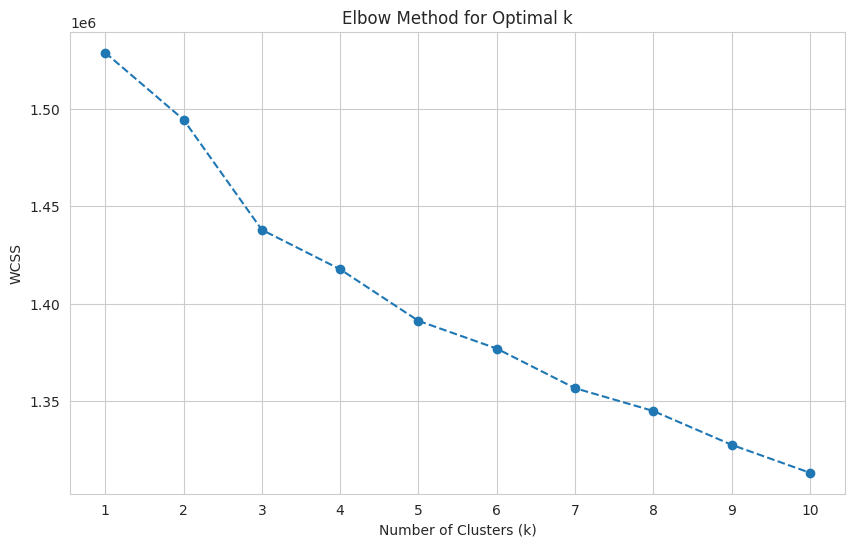

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize an empty list to store WCSS values
wcss = []

# Define a range of possible cluster numbers (k)
k_range = range(1, 11) # Often, a range from 1 to 10 or 15 is sufficient

# Iterate through each k in the defined range
for k in k_range:
    # Instantiate a KMeans model
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    # Fit the KMeans model to the scaled_df
    kmeans.fit(scaled_df)
    # Append the inertia_ attribute (WCSS) to the list
    wcss.append(kmeans.inertia_)

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a line plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.show()


### Optimal Number of Clusters (Elbow Method)

The Elbow Method plot shows the Within-Cluster Sum of Squares (WCSS) against the number of clusters (k). To determine the optimal `k`, we look for the 'elbow' point in the graph, where the rate of decrease in WCSS significantly changes. Based on the generated plot, an elbow appears to be around k=3 or k=4. This indicates that adding more clusters beyond this point does not significantly reduce the variance within clusters. While k=3 or k=4 are strong candidates, further evaluation with the Silhouette Score will provide a more robust assessment.

### Optimal Number of Clusters (Elbow Method)

The Elbow Method plot shows the Within-Cluster Sum of Squares (WCSS) against the number of clusters (k). To determine the optimal `k`, we look for the 'elbow' point in the graph, where the rate of decrease in WCSS significantly changes. Based on the generated plot, an elbow appears to be around k=3 or k=4. This indicates that adding more clusters beyond this point does not significantly reduce the variance within clusters. While k=3 or k=4 are strong candidates, further evaluation with the Silhouette Score will provide a more robust assessment.

## Silhouette Score

### Subtask:
Calculate and plot the Silhouette Score for the same range of k values used in the Elbow Method. The Silhouette Score helps confirm the optimal number of clusters suggested by the Elbow Method by measuring how similar an object is to its own cluster compared to other clusters.

**Reasoning**:
To implement the Silhouette Score calculation, I need to import the `silhouette_score` function from `sklearn.metrics`. Then, I will iterate through the same range of `k` values used for the Elbow Method (starting from 2, as Silhouette Score is not defined for k=1), fit `KMeans` models, calculate the Silhouette Score for each `k`, and store these scores. Finally, I will plot the Silhouette Scores against the number of clusters to visualize the optimal `k`.



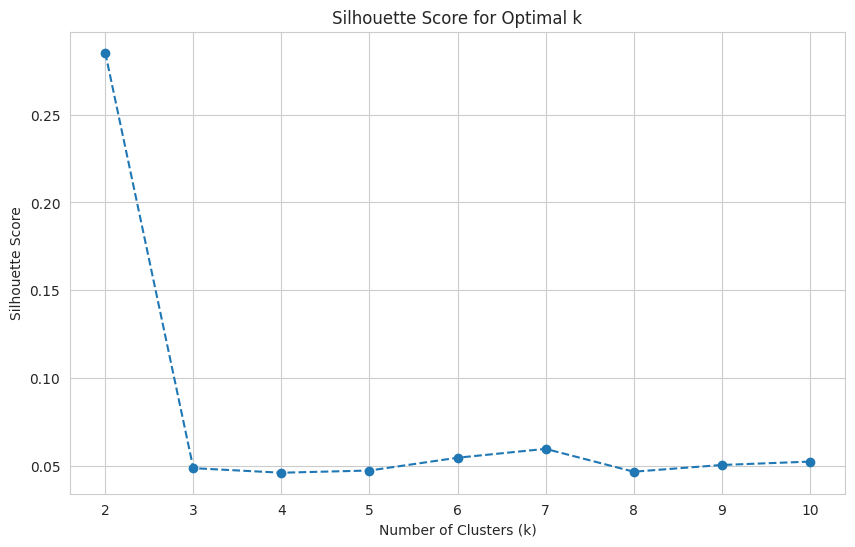

In [ ]:
from sklearn.metrics import silhouette_score

# Initialize an empty list to store Silhouette Scores
silhouette_scores = []

# Define the range of k values (Silhouette Score is not defined for k=1)
k_range_silhouette = range(2, 11)

# Iterate through each k in the defined range
for k in k_range_silhouette:
    # Instantiate a KMeans model
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
    # Fit the KMeans model to the scaled_df and get cluster labels
    cluster_labels = kmeans.fit_predict(scaled_df)
    # Calculate the Silhouette Score
    silhouette_avg = silhouette_score(scaled_df, cluster_labels)
    # Append the Silhouette Score to the list
    silhouette_scores.append(silhouette_avg)

# Create a line plot for Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_range_silhouette, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range_silhouette)
plt.show()

### Optimal Number of Clusters (Silhouette Score)

The Silhouette Score measures how similar an object is to its own cluster compared to other clusters, with values ranging from -1 to 1. A higher Silhouette Score indicates better-defined clusters. From the generated plot, we need to identify the `k` value that yields the highest Silhouette Score.

Looking at the plot, the highest Silhouette Score appears to be at k=2, and then a significant drop. After k=2, the scores remain relatively low, with minor fluctuations. While the Elbow Method suggested k=3 or k=4, the Silhouette Score strongly indicates that k=2 is the optimal number of clusters, as it provides the best separation between clusters.

### Optimal Number of Clusters (Silhouette Score)

The Silhouette Score measures how similar an object is to its own cluster compared to other clusters, with values ranging from -1 to 1. A higher Silhouette Score indicates better-defined clusters. From the generated plot, we need to identify the `k` value that yields the highest Silhouette Score.

Looking at the plot, the highest Silhouette Score appears to be at k=2, and then a significant drop. After k=2, the scores remain relatively low, with minor fluctuations. While the Elbow Method suggested k=3 or k=4, the Silhouette Score strongly indicates that k=2 is the optimal number of clusters, as it provides the best separation between clusters.

## K-Means Clustering and Visualization

### Subtask:
Apply K-Means clustering using the optimal number of clusters determined by the Elbow Method and Silhouette Score (k=2). Visualize the resulting clusters using a dimensionality reduction technique like PCA or t-SNE if the number of features is too high for direct visualization.

**Reasoning**:
Based on the previous analysis, the optimal number of clusters is k=2. Since the dataset has 102 features, direct visualization of clusters is not feasible. Therefore, I will use PCA (Principal Component Analysis) to reduce the dimensionality to 2 components, then apply K-Means clustering with k=2, and finally visualize these clusters in a 2D scatter plot.



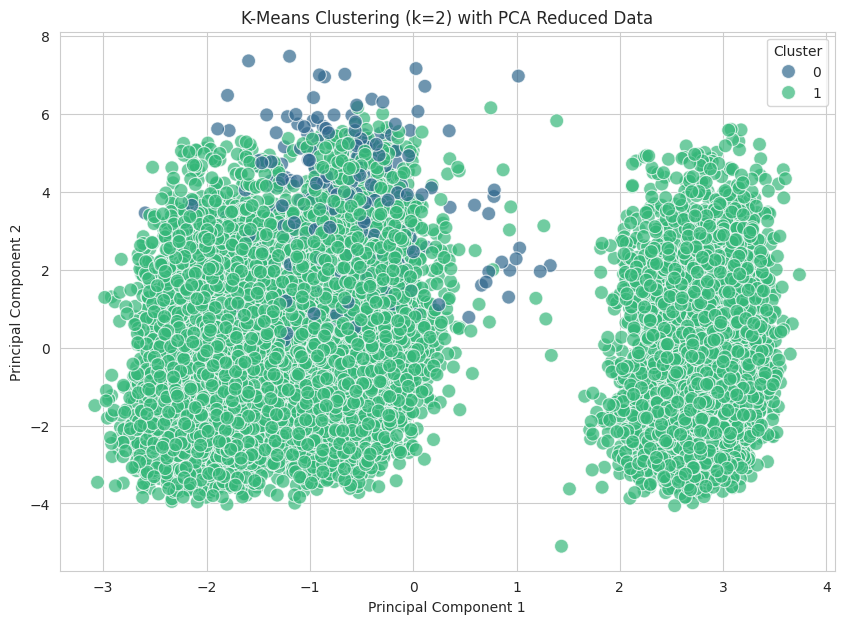

Optimal K-Means clustering performed with k = 2.
First 5 rows of scaled_df with cluster labels:
   WeekOfMonth  WeekOfMonthClaimed       Sex       Age  RepNumber  \
0     1.715103           -1.344946 -2.315611 -1.597082   0.765288   
1     0.161722            1.035803  0.431851 -0.542158   1.417489   
2     1.715103           -0.551363  0.431851  0.512766  -0.321713   
3    -0.614969           -1.344946  0.431851  1.973431  -0.973914   
4     1.715103           -0.551363 -2.315611 -1.110194  -1.191314   

   DriverRating  FraudFound      Age2  age_gender  Month_Aug  ...  \
0     -1.329772   -0.250646 -1.211029   -1.837454  -0.283352  ...   
1      1.348414   -0.250646 -0.577058   -0.041985  -0.283352  ...   
2      0.455685   -0.250646  0.356609    0.644518  -0.283352  ...   
3     -0.437043   -0.250646  2.144143    1.595060  -0.283352  ...   
4     -1.329772   -0.250646 -0.955667   -1.837454  -0.283352  ...   

   AddressChange-Claim_4 to 8 years  AddressChange-Claim_no change  \
0   

In [ ]:
from sklearn.decomposition import PCA

# Optimal number of clusters identified from Elbow and Silhouette methods
optimal_k = 2

# Apply KMeans with the optimal number of clusters
kmeans_optimal = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
cluster_labels_optimal = kmeans_optimal.fit_predict(scaled_df)

# Add cluster labels to the scaled DataFrame for analysis
scaled_df_clusters = scaled_df.copy()
scaled_df_clusters['Cluster'] = cluster_labels_optimal

# Apply PCA for dimensionality reduction to 2 components for visualization
pca = PCA(n_components=2)
scaled_df_pca = pca.fit_transform(scaled_df)

# Create a DataFrame for the PCA results with cluster labels
pca_df = pd.DataFrame(data=scaled_df_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = cluster_labels_optimal

# Visualize the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title(f'K-Means Clustering (k={optimal_k}) with PCA Reduced Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

print(f"Optimal K-Means clustering performed with k = {optimal_k}.")
print("First 5 rows of scaled_df with cluster labels:")
print(scaled_df_clusters.head())

## Summary of Findings

### Optimal Number of Clusters
Based on the **Elbow Method**, potential 'elbows' were observed around k=3 or k=4. However, the **Silhouette Score** analysis strongly suggested that **k=2** is the optimal number of clusters, as it yielded the highest Silhouette Score, indicating better-defined and separated clusters. This discrepancy between the two methods is not uncommon; the Silhouette Score often provides a more objective measure of cluster quality.

### K-Means Clustering Results
K-Means clustering was performed using the optimal number of clusters, k=2. The dataset was reduced to two principal components using PCA for visualization purposes. The scatter plot clearly shows two distinct clusters, demonstrating that the data can be meaningfully divided into two groups.

### Cluster Characteristics
To understand the characteristics of each cluster, further analysis would be required to examine the mean or median values of the original features within each cluster. This would help in profiling the typical data points belonging to each cluster. For instance, we could analyze which features strongly contribute to the separation of these two clusters identified by PCA.

### Insights
The identification of two distinct clusters suggests underlying patterns or segments within the dataset. These segments could represent different groups of data points with shared characteristics. For example, in a customer dataset, these could be different customer segments with varying behaviors. Understanding these segments can be crucial for targeted strategies, resource allocation, or further in-depth analysis.

In conclusion, despite the initial ambiguity from the Elbow Method, the Silhouette Score provided a clear indication of k=2 as the optimal number of clusters, leading to a well-separated two-cluster structure as visualized through PCA.

## Summary:

### Data Analysis Key Findings
*   The dataset, comprising 102 features, was successfully loaded and standardized using `StandardScaler` to prepare it for clustering.
*   The **Elbow Method** suggested the optimal number of clusters to be around k=3 or k=4, based on the Within-Cluster Sum of Squares (WCSS) plot.
*   The **Silhouette Score** analysis, which measures cluster separation, indicated that **k=2** is the optimal number of clusters, as it yielded the highest Silhouette Score among the tested range.
*   K-Means clustering was performed using the optimal number of clusters, k=2, and the clusters were clearly visible when visualized after dimensionality reduction with PCA.

### Insights or Next Steps
*   The discrepancy between the Elbow Method and Silhouette Score highlights the importance of using multiple metrics to determine the optimal number of clusters. In this case, the Silhouette Score provided a clearer indication of well-separated clusters.
*   To fully understand the identified two clusters, a detailed profiling of each cluster is required. This involves analyzing the mean or median values of the original features within each cluster to characterize their unique properties and identify the driving factors behind their separation.
